<a href="https://colab.research.google.com/github/karib3/ML-Engineering/blob/main/Classification/Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement:
Detect if a woman has breast cancer from the provided features.

#Data Collection:

In [ ]:
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


In [ ]:
actual_path = path + "/data.csv"

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(actual_path)

#Exploratory Data Analysis (EDA):

In [ ]:
df.shape

(569, 33)

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
id,569.0,30371831.4,125020585.6,8670.0,869218.0,906024.0,8813129.0,911320502.0
radius_mean,569.0,14.1,3.5,7.0,11.7,13.4,15.8,28.1
texture_mean,569.0,19.3,4.3,9.7,16.2,18.8,21.8,39.3
perimeter_mean,569.0,92.0,24.3,43.8,75.2,86.2,104.1,188.5
area_mean,569.0,654.9,351.9,143.5,420.3,551.1,782.7,2501.0
smoothness_mean,569.0,0.1,0.0,0.1,0.1,0.1,0.1,0.2
compactness_mean,569.0,0.1,0.1,0.0,0.1,0.1,0.1,0.3
concavity_mean,569.0,0.1,0.1,0.0,0.0,0.1,0.1,0.4
concave points_mean,569.0,0.0,0.0,0.0,0.0,0.0,0.1,0.2
symmetry_mean,569.0,0.2,0.0,0.1,0.2,0.2,0.2,0.3


In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis']

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
info = pd.DataFrame({
    'dtypes': df.dtypes,
    'missing': df.isna().sum(),
    'unique': df.nunique(),
    'correlation': df.corr()['diagnosis']
}).sort_values(by='correlation', ascending=False)

info

,dtypes,missing,unique,correlation
diagnosis,int64,0,2,1.000000
concave points_worst,float64,0,492,0.793566
perimeter_worst,float64,0,514,0.782914
concave points_mean,float64,0,542,0.776614
radius_worst,float64,0,457,0.776454
perimeter_mean,float64,0,522,0.742636
area_worst,float64,0,544,0.733825
radius_mean,float64,0,456,0.730029
area_mean,float64,0,539,0.708984
concavity_mean,float64,0,537,0.696360


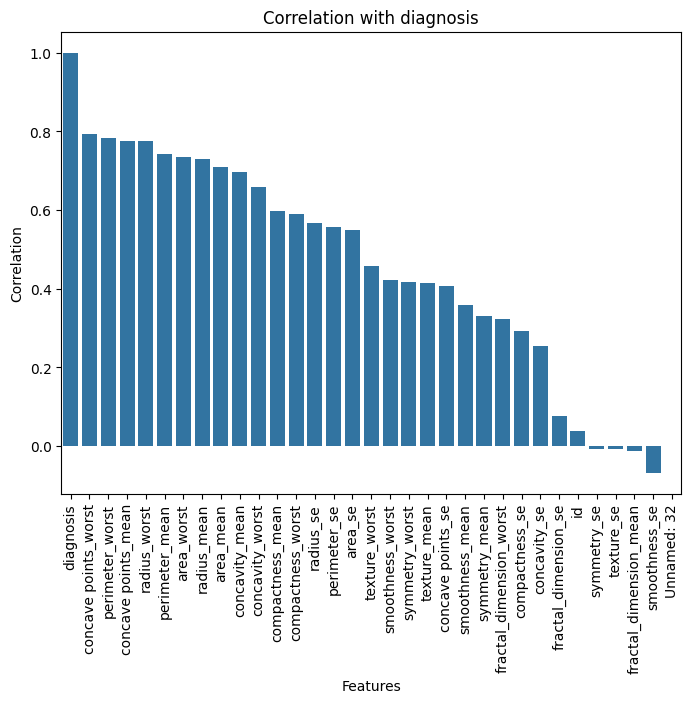

In [ ]:
#Correlation with target variable
plt.figure(figsize=(8, 6))
sns.barplot(x=info.index, y=info['correlation'])
plt.xticks(rotation=90)
plt.title('Correlation with diagnosis')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()

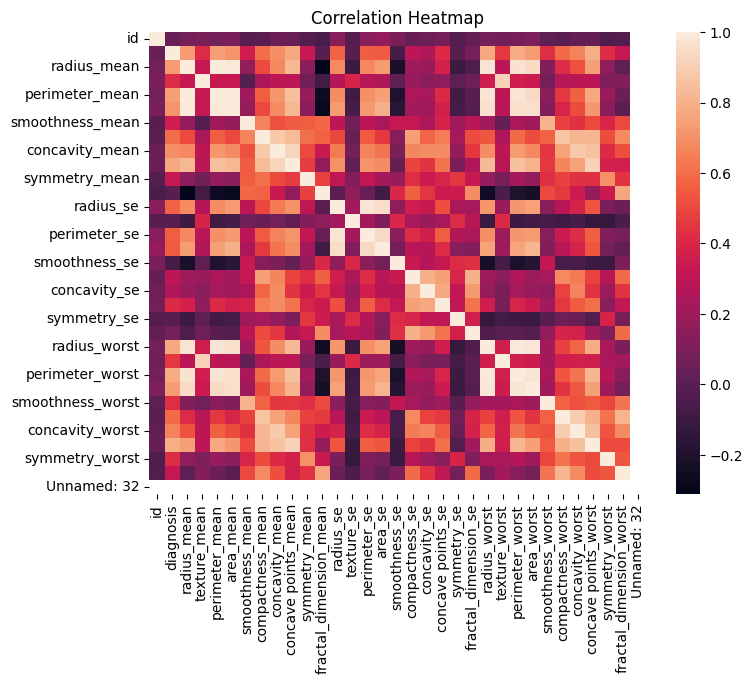

In [ ]:
#Checking collinearity
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")
plt.show()

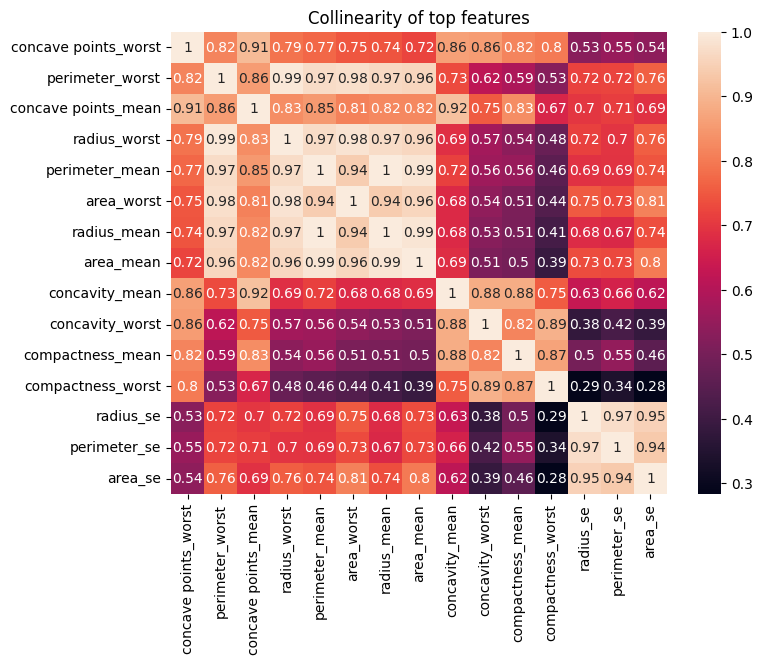

In [ ]:
#Collinearity of top features i.e. correlation >= 0.5
top_features = ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst', 'compactness_mean', 'compactness_worst', 'radius_se', 'perimeter_se', 'area_se']

plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr(), annot=True)
plt.title("Collinearity of top features")
plt.show()

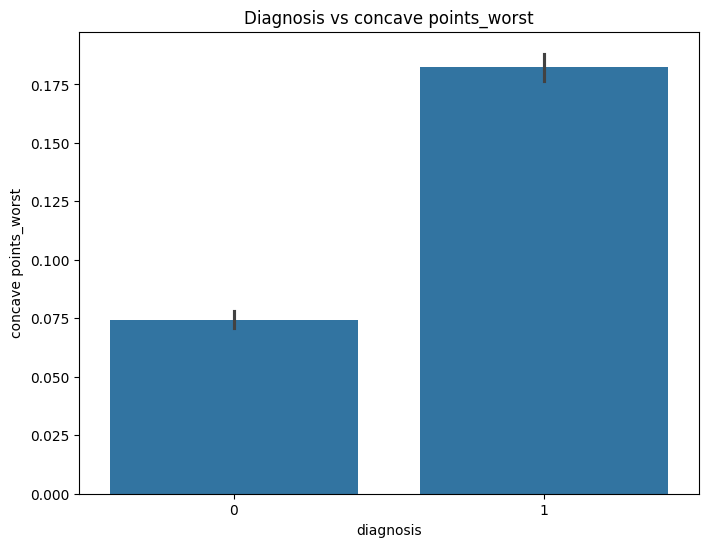

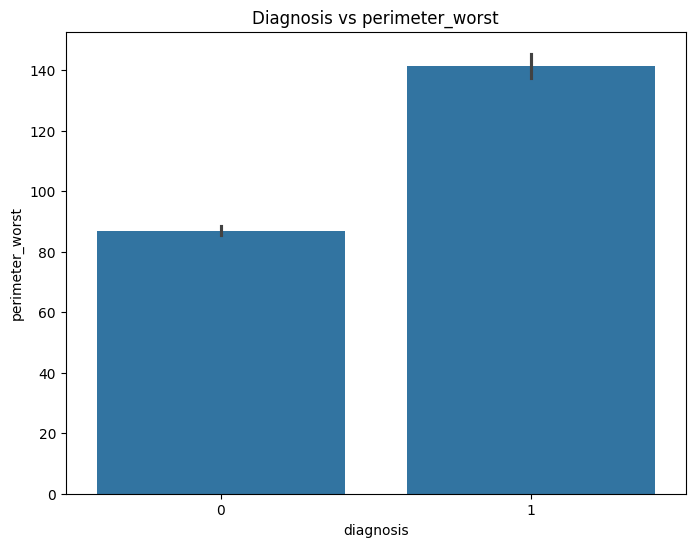

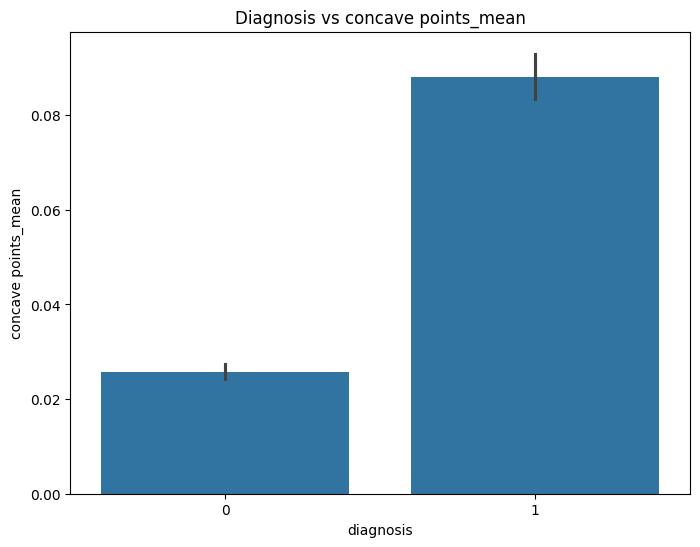

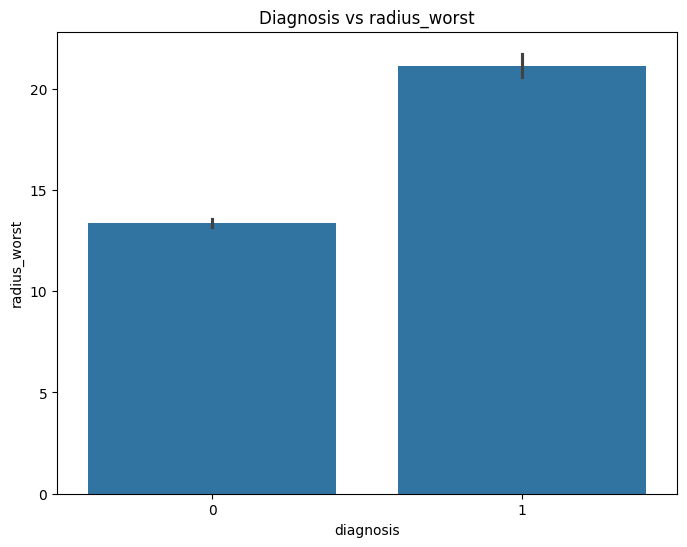

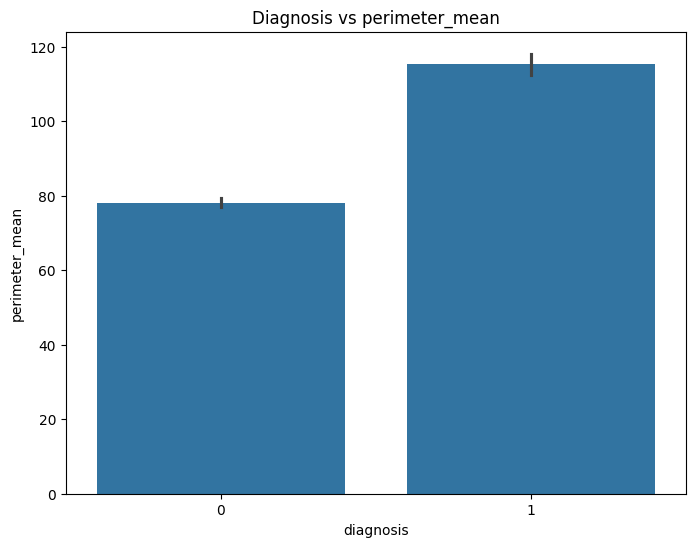

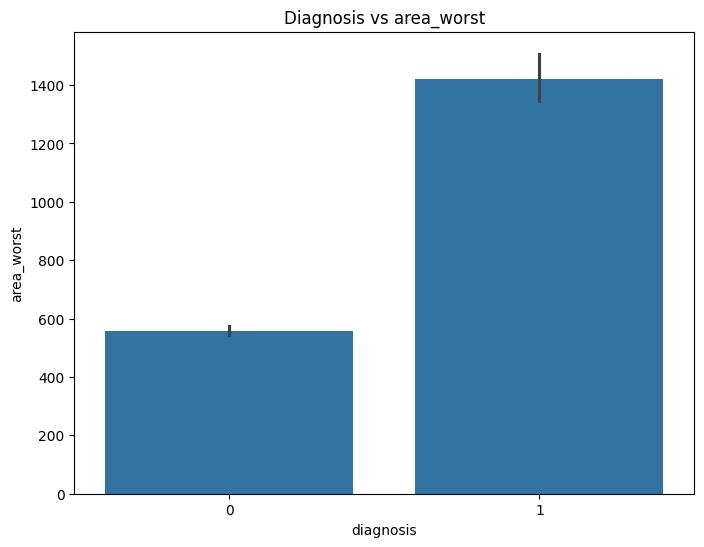

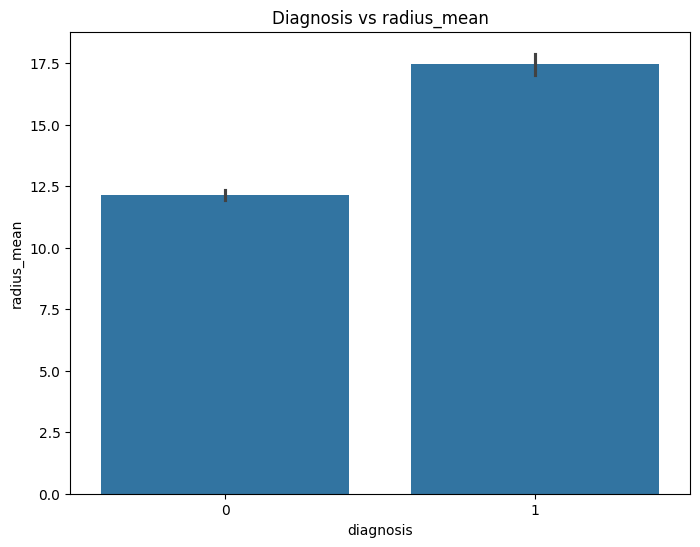

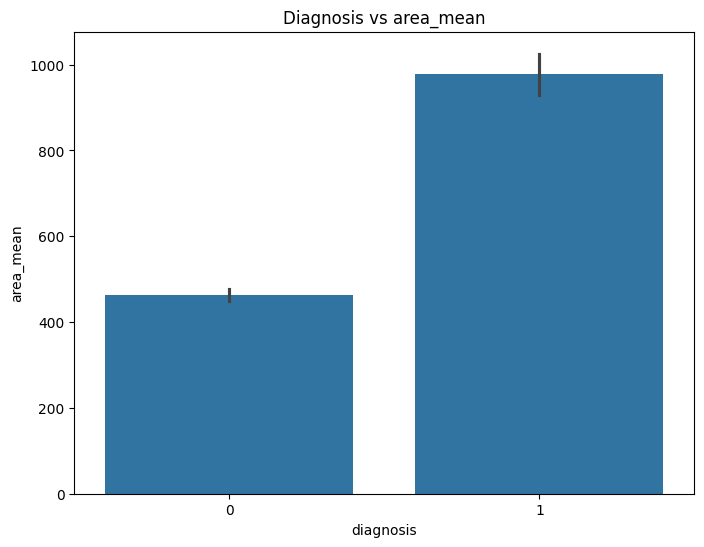

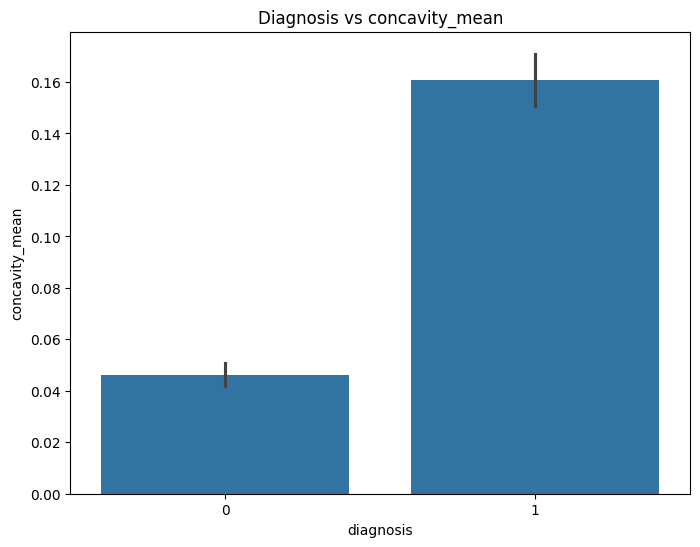

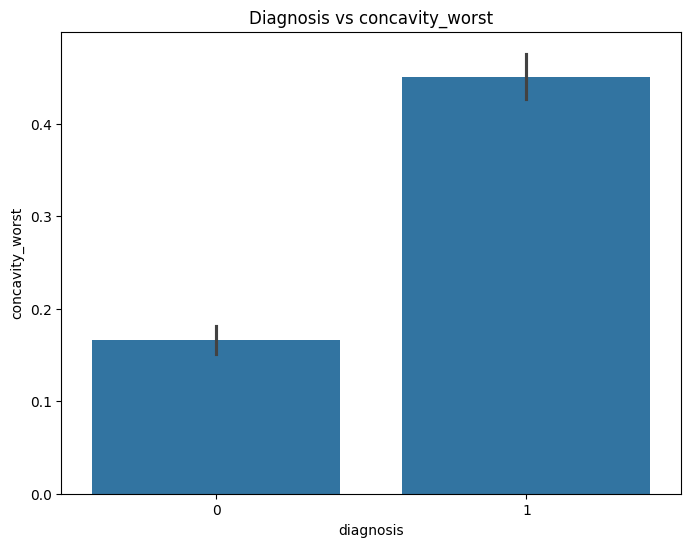

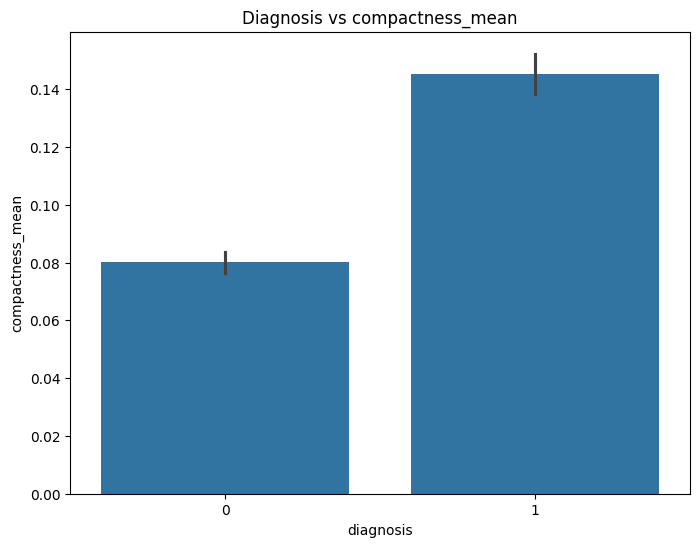

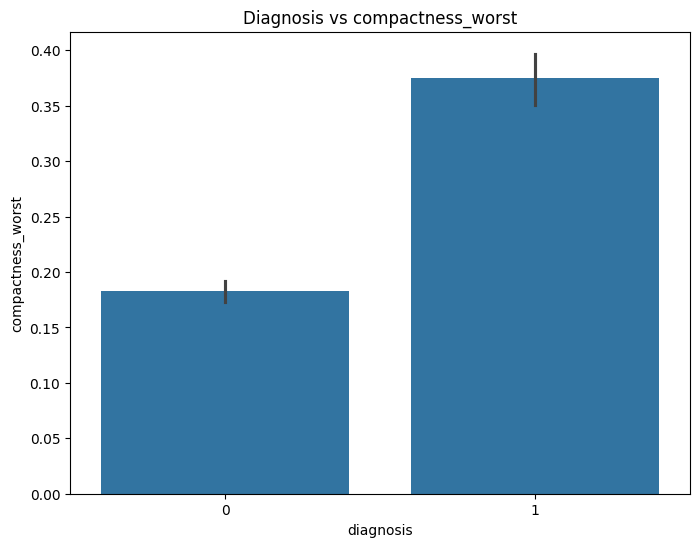

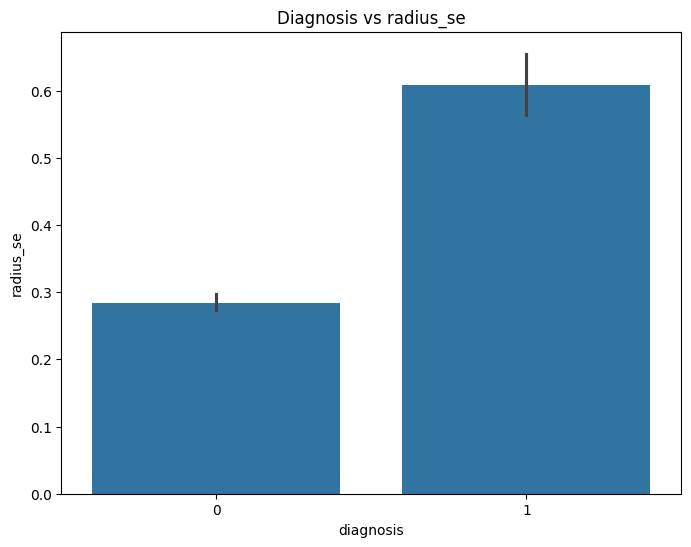

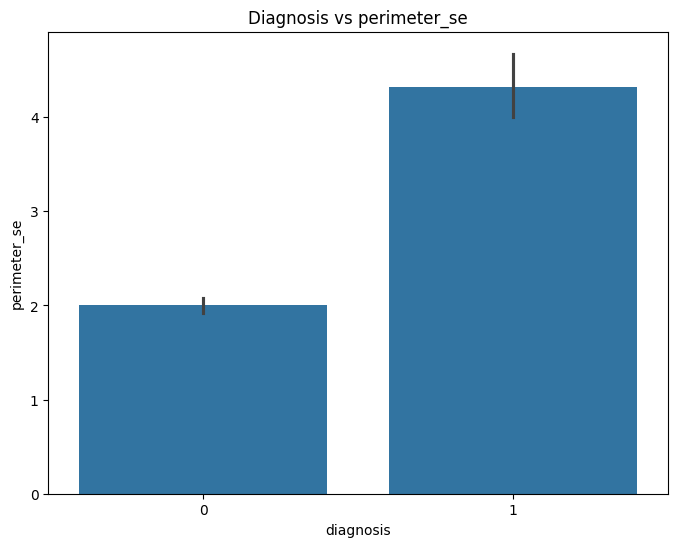

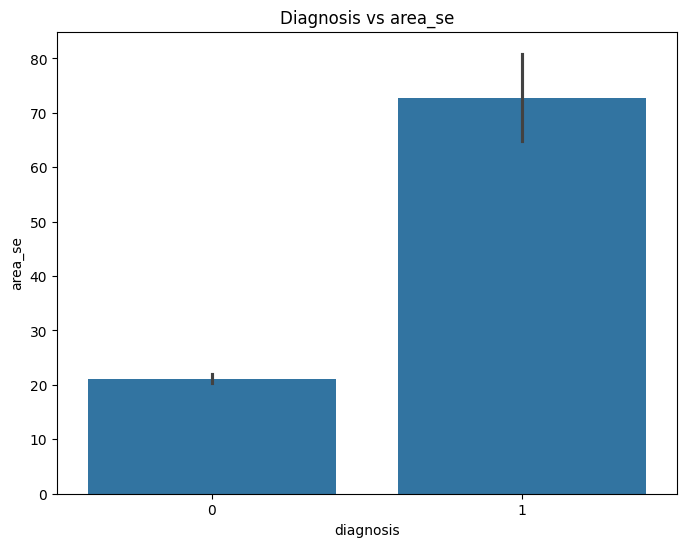

In [ ]:
for feature in top_features:
    plt.figure(figsize=(8, 6))
    sns.barplot(x=df['diagnosis'], y=df[feature])
    plt.title(f'Diagnosis vs {feature}')
    plt.xlabel

In [ ]:
df['diagnosis'].describe()

,diagnosis
count,569.000000
mean,0.372583
std,0.483918
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


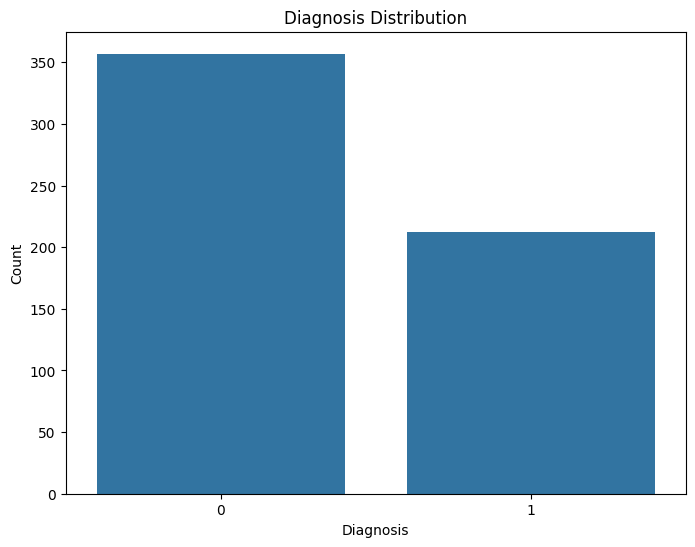

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df)
plt.title('Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [ ]:
df['diagnosis'].value_counts(normalize=True)

,proportion
diagnosis,
0,0.627417
1,0.372583


#Data Cleaning:

In [ ]:
df_clean = df.drop(columns=['id', 'Unnamed: 32'])

In [ ]:
df_clean.shape

(569, 31)

In [ ]:
df_clean

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


#Train-Test-Split:

In [ ]:
X = df_clean.drop('diagnosis', axis=1)
y = df_clean['diagnosis']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [ ]:
y_train.value_counts(normalize=True)

,proportion
diagnosis,
0,0.626374
1,0.373626


In [ ]:
y_test.value_counts(normalize=True)

,proportion
diagnosis,
0,0.631579
1,0.368421


#Preprocessing:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),

    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),

    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ]),

    "Naive Bayes": Pipeline([
        ('model', GaussianNB())
    ]),

    "Decision Tree": Pipeline([
        ('model', DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ('model', RandomForestClassifier(random_state=42))
    ]),

    "Gradient Boosting": Pipeline([
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
KNN trained.
SVM trained.
Naive Bayes trained.
Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.


#Baseline Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Probability/decision score for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

baseline_results = pd.DataFrame(results)
baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
1,KNN,0.9561,0.9744,0.9048,0.9383,0.9823
2,SVM,0.9737,1.0000,0.9286,0.9630,0.9947
3,Naive Bayes,0.9386,1.0000,0.8333,0.9091,0.9934
4,Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246
5,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929
6,Gradient Boosting,0.9649,1.0000,0.9048,0.9500,0.9947


In [ ]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)


Logistic Regression
[[71  1]
 [ 3 39]]

KNN
[[71  1]
 [ 4 38]]

SVM
[[72  0]
 [ 3 39]]

Naive Bayes
[[72  0]
 [ 7 35]]

Decision Tree
[[68  4]
 [ 4 38]]

Random Forest
[[72  0]
 [ 3 39]]

Gradient Boosting
[[72  0]
 [ 4 38]]


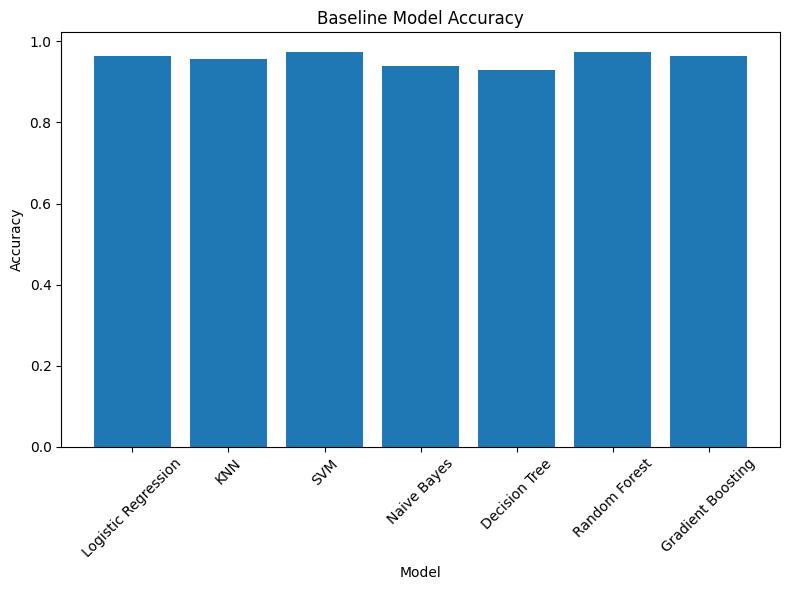

In [ ]:
plt.figure(figsize=(8, 6))

plt.bar(
    baseline_results["Model"],
    baseline_results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Baseline Model Accuracy")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
training_results = []

for name, model in models.items():

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    training_results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred)
    })

train_test_results = pd.DataFrame(training_results)

train_test_results["Gap"] = (
    train_test_results["Train Accuracy"]
    - train_test_results["Test Accuracy"]
)

train_test_results.round(4)

,Model,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression,0.9868,0.9649,0.0219
1,KNN,0.9780,0.9561,0.0219
2,SVM,0.9868,0.9737,0.0131
3,Naive Bayes,0.9429,0.9386,0.0043
4,Decision Tree,1.0000,0.9298,0.0702
5,Random Forest,1.0000,0.9737,0.0263
6,Gradient Boosting,1.0000,0.9649,0.0351


#Hyperparameter Tuning with GridSearchCV

In [ ]:
logistic_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

svm_params = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto", 0.01, 0.1, 1]
}

nb_params = {
    "model__var_smoothing": [
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6
    ]
}

dt_params = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8]
}

rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

gb_params = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

pipelines = {
    "Logistic Regression": models['Logistic Regression'],
    "KNN": models['KNN'],
    "SVM": models['SVM'],
    "Naive Bayes": models['Naive Bayes'],
    "Decision Tree": models['Decision Tree'],
    "Random Forest": models['Random Forest'],
    "Gradient Boosting": models['Gradient Boosting']
}

param_grids = {
    "Logistic Regression": logistic_params,
    "KNN": knn_params,
    "SVM": svm_params,
    "Naive Bayes": nb_params,
    "Decision Tree": dt_params,
    "Random Forest": rf_params,
    "Gradient Boosting": gb_params
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_results = {}
best_models = {}

for name in pipelines:

    print(f"Running GridSearchCV for {name}...")

    grid = GridSearchCV(
        estimator=pipelines[name],
        param_grid=param_grids[name],
        scoring="f1",
        cv=5,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    grid_results[name] = grid
    best_models[name] = grid.best_estimator_

    print(f"Best F1: {grid.best_score_:.4f}")
    print(f"Best Parameters: {grid.best_params_}")
    print()

Running GridSearchCV for Logistic Regression...
Best F1: 0.9662
Best Parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}

Running GridSearchCV for KNN...
Best F1: 0.9573
Best Parameters: {'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}

Running GridSearchCV for SVM...
Best F1: 0.9647
Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Running GridSearchCV for Naive Bayes...
Best F1: 0.9209
Best Parameters: {'model__var_smoothing': 1e-09}

Running GridSearchCV for Decision Tree...
Best F1: 0.9329
Best Parameters: {'model__criterion': 'entropy', 'model__max_depth': 6, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5}

Running GridSearchCV for Random Forest...
Best F1: 0.9501
Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Running GridSearchCV for Gradient Boosting...
Best F1: 0.9532
Best Parameters: {'

In [ ]:
tuning_results = []

for name, grid in grid_results.items():

    tuning_results.append({
        "Model": name,
        "Best CV F1": grid.best_score_,
        "Best Parameters": grid.best_params_
    })

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df["Best CV F1"] = (
    tuning_results_df["Best CV F1"].round(4)
)

tuning_results_df

,Model,Best CV F1,Best Parameters
0,Logistic Regression,0.9662,"{'model__C': 0.1, 'model__solver': 'liblinear'}"
1,KNN,0.9573,"{'model__n_neighbors': 3, 'model__p': 1, 'mode..."
2,SVM,0.9647,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
3,Naive Bayes,0.9209,{'model__var_smoothing': 1e-09}
4,Decision Tree,0.9329,"{'model__criterion': 'entropy', 'model__max_de..."
5,Random Forest,0.9501,"{'model__max_depth': None, 'model__max_feature..."
6,Gradient Boosting,0.9532,"{'model__learning_rate': 0.2, 'model__max_dept..."


#Tuned Models Evaluation

In [ ]:
tuned_results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9825,1.0,0.9524,0.9756,0.9977
1,KNN,0.9649,1.0,0.9048,0.9500,0.9735
2,SVM,0.9737,1.0,0.9286,0.9630,0.9927
3,Naive Bayes,0.9386,1.0,0.8333,0.9091,0.9934
4,Decision Tree,0.9386,1.0,0.8333,0.9091,0.9507
5,Random Forest,0.9737,1.0,0.9286,0.9630,0.9929
6,Gradient Boosting,0.9649,1.0,0.9048,0.9500,0.9947


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

tuned_confusion_matrices = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    tuned_confusion_matrices[name] = cm

    print(f"\n{name}")
    print(cm)


Logistic Regression
[[72  0]
 [ 2 40]]

KNN
[[72  0]
 [ 4 38]]

SVM
[[72  0]
 [ 3 39]]

Naive Bayes
[[72  0]
 [ 7 35]]

Decision Tree
[[72  0]
 [ 7 35]]

Random Forest
[[72  0]
 [ 3 39]]

Gradient Boosting
[[72  0]
 [ 4 38]]


In [ ]:
cv_summary = []

for name, grid in grid_results.items():
    idx = grid.best_index_

    mean_train_f1 = grid.cv_results_["mean_train_score"][idx]
    mean_cv_f1 = grid.cv_results_["mean_test_score"][idx]

    cv_summary.append({
        "Model": name,
        "Mean Train F1": mean_train_f1,
        "Mean CV F1": mean_cv_f1,
        "CV Gap": mean_train_f1 - mean_cv_f1
    })

cv_summary_df = pd.DataFrame(cv_summary)

cv_summary_df.round(4)

,Model,Mean Train F1,Mean CV F1,CV Gap
0,Logistic Regression,0.9762,0.9662,0.0100
1,KNN,0.9744,0.9573,0.0171
2,SVM,0.9866,0.9647,0.0218
3,Naive Bayes,0.9258,0.9209,0.0049
4,Decision Tree,0.9881,0.9329,0.0552
5,Random Forest,1.0000,0.9501,0.0499
6,Gradient Boosting,1.0000,0.9532,0.0468


#Final results

In [ ]:
final_comparison = baseline_results.copy()

final_comparison = final_comparison.merge(
    tuned_results_df,
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

final_comparison = final_comparison.merge(
    cv_summary_df,
    on="Model"
)

final_comparison.round(4)

,Model,Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1_Baseline,ROC-AUC_Baseline,Accuracy_Tuned,Precision_Tuned,Recall_Tuned,F1_Tuned,ROC-AUC_Tuned,Mean Train F1,Mean CV F1,CV Gap
0,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960,0.9825,1.0,0.9524,0.9756,0.9977,0.9762,0.9662,0.0100
1,KNN,0.9561,0.9744,0.9048,0.9383,0.9823,0.9649,1.0,0.9048,0.9500,0.9735,0.9744,0.9573,0.0171
2,SVM,0.9737,1.0000,0.9286,0.9630,0.9947,0.9737,1.0,0.9286,0.9630,0.9927,0.9866,0.9647,0.0218
3,Naive Bayes,0.9386,1.0000,0.8333,0.9091,0.9934,0.9386,1.0,0.8333,0.9091,0.9934,0.9258,0.9209,0.0049
4,Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246,0.9386,1.0,0.8333,0.9091,0.9507,0.9881,0.9329,0.0552
5,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929,0.9737,1.0,0.9286,0.9630,0.9929,1.0000,0.9501,0.0499
6,Gradient Boosting,0.9649,1.0000,0.9048,0.9500,0.9947,0.9649,1.0,0.9048,0.9500,0.9947,1.0000,0.9532,0.0468


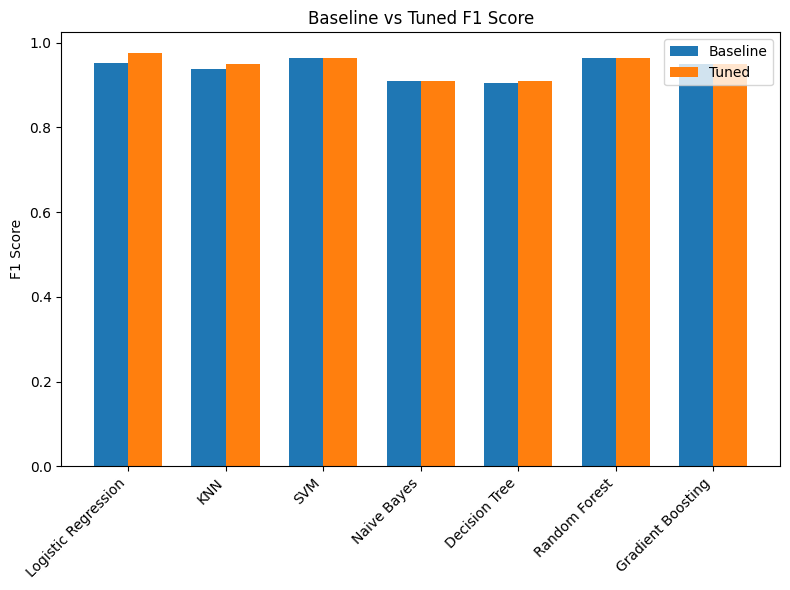

In [ ]:
models = final_comparison["Model"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 6))

plt.bar(
    x - width/2,
    final_comparison["F1_Baseline"],
    width,
    label="Baseline"
)

plt.bar(
    x + width/2,
    final_comparison["F1_Tuned"],
    width,
    label="Tuned"
)

plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Baseline vs Tuned F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

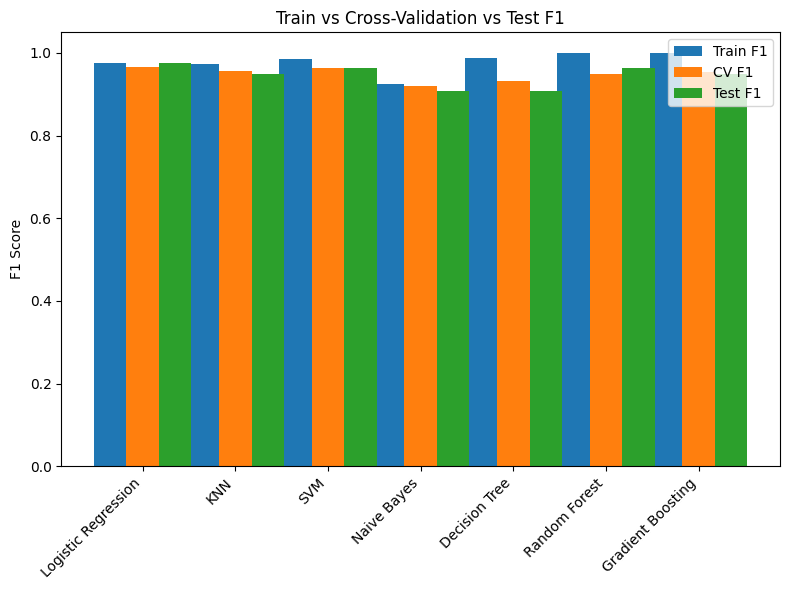

In [ ]:
plt.figure(figsize=(8, 6))

plt.bar(
    x - width,
    final_comparison["Mean Train F1"],
    width,
    label="Train F1"
)

plt.bar(
    x,
    final_comparison["Mean CV F1"],
    width,
    label="CV F1"
)

plt.bar(
    x + width,
    final_comparison["F1_Tuned"],
    width,
    label="Test F1"
)

plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Train vs Cross-Validation vs Test F1")
plt.legend()
plt.tight_layout()
plt.show()

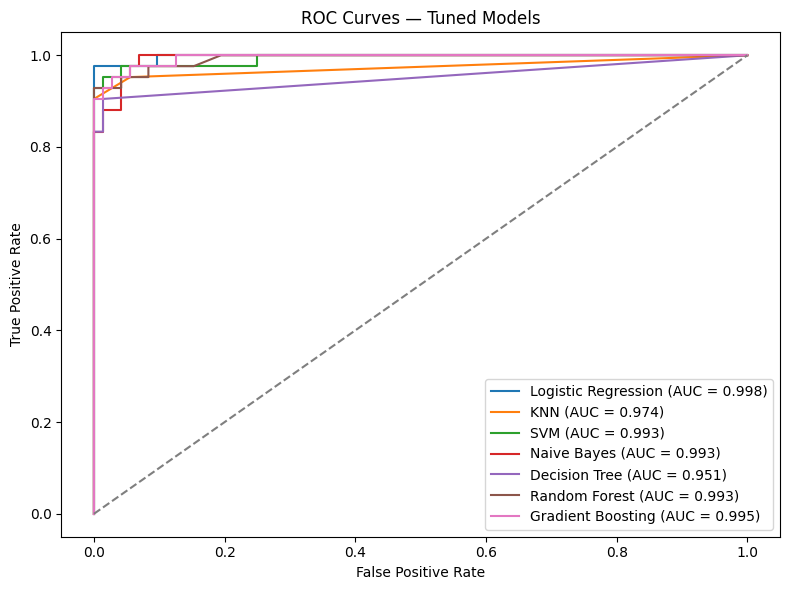

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, model in best_models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Tuned Models")
plt.legend()
plt.tight_layout()
plt.show()

#Conclusion

This project implemented a complete binary classification workflow using the Breast Cancer Wisconsin (Diagnostic) dataset. Seven different classification algorithms were trained and compared: Logistic Regression, KNN, SVM, Gaussian Naive Bayes, Decision Tree, Random Forest, and Gradient Boosting.

The baseline models demonstrated that the dataset can be classified with relatively high predictive performance. Hyperparameter optimization using 5-fold GridSearchCV was then performed using F1-score as the optimization metric. The results showed that tuning does not necessarily improve every model on the held-out test set, but it can improve generalization for particular algorithms and hyperparameter configurations.

Logistic Regression showed the strongest test-set performance in this experiment after tuning, achieving an accuracy of **98.25%**, precision of **100%**, recall of **95.24%**, F1-score of **97.56%**, and ROC-AUC of **99.77%**. Its confusion matrix contained only two false negatives and no false positives on the test set.

The confusion-matrix analysis also demonstrated why accuracy alone is insufficient for classification problems. Although several models achieved 100% precision, they differed in recall and therefore in the number of malignant cases they failed to identify. This highlighted the importance of examining multiple evaluation metrics and individual error types.

The cross-validation analysis provided additional insight into model generalization. Logistic Regression had a relatively small train-to-CV F1 gap of **0.0100**, while the Decision Tree, Random Forest, and Gradient Boosting models showed larger gaps. In particular, the Decision Tree had a CV gap of **0.0552**, indicating stronger evidence of overfitting despite hyperparameter tuning.

Overall, this project demonstrated the complete machine-learning workflow from data exploration and preprocessing through baseline modeling, cross-validation, hyperparameter optimization, evaluation, and generalization analysis. It also demonstrated why model selection should consider multiple metrics and the underlying error characteristics rather than relying on accuracy alone.

The main takeaway is that **hyperparameter tuning, cross-validation, and careful evaluation are essential for understanding how well a classification model is likely to generalize to unseen data.**


#Classification Project Steps

## Steps Performed

1. **Problem Definition**

   * Defined the task as a binary classification problem for predicting whether a breast tumor is **Benign (B)** or **Malignant (M)**.
   * Encoded the target variable as:

     * `0` → Benign
     * `1` → Malignant

2. **Data Loading and Initial Inspection**

   * Loaded the Breast Cancer Wisconsin (Diagnostic) dataset.
   * Examined the dataset shape, data types, missing values, unique values, and descriptive statistics.
   * The dataset contained 569 observations and 33 columns initially.

3. **Exploratory Data Analysis**

   * Analyzed the class distribution.
   * Investigated feature correlations with the target variable.
   * Examined correlations between features to identify multicollinearity.
   * Identified highly correlated features but did not remove them solely based on correlation because correlation alone is not sufficient evidence that a feature is uninformative.

4. **Data Cleaning**

   * Removed `Unnamed: 32` because it contained no useful values.
   * Removed `id` because it is an identifier rather than a predictive feature.
   * Checked for duplicate observations.
   * Verified that the remaining features did not contain missing values requiring imputation.

5. **Train-Test Split**

   * Separated the features and target variable.
   * Split the data into training and testing sets using an 80/20 split.
   * Used stratification to preserve the class distribution in both sets.
   * Set `random_state=42` for reproducibility.

6. **Preprocessing**

   * Applied `StandardScaler` to models that are sensitive to feature scale:

     * Logistic Regression
     * KNN
     * SVM
   * Used unscaled features for tree-based models and Gaussian Naive Bayes.
   * Implemented preprocessing using Scikit-learn `Pipeline` to prevent data leakage during cross-validation.

7. **Baseline Model Development**

   * Trained and evaluated seven classification algorithms:

     * Logistic Regression
     * K-Nearest Neighbors (KNN)
     * Support Vector Machine (SVM)
     * Gaussian Naive Bayes
     * Decision Tree
     * Random Forest
     * Gradient Boosting

8. **Baseline Model Evaluation**

   * Evaluated each model using:

     * Accuracy
     * Precision
     * Recall
     * F1-score
     * ROC-AUC
   * Generated confusion matrices.
   * Compared training and test performance to investigate potential overfitting.

9. **Hyperparameter Optimization**

   * Applied `GridSearchCV` with 5-fold cross-validation.
   * Used **F1-score** as the optimization metric.
   * Tuned relevant hyperparameters for all seven models.
   * Used only the training data during hyperparameter search so that the test set remained unseen.

10. **Tuned Model Evaluation**

    * Retrieved the best hyperparameters from each GridSearchCV search.
    * Evaluated the resulting tuned models on the held-out test set.
    * Compared tuned performance against the baseline models.

11. **Confusion Matrix Analysis**

    * Examined TN, FP, FN, and TP for each tuned model.
    * Compared the types of classification errors made by different algorithms.
    * Investigated false negatives in particular because they represent malignant cases classified as benign.

12. **Generalization Analysis**

    * Compared mean training F1-score with mean cross-validation F1-score.
    * Calculated the CV generalization gap.
    * Compared CV performance with final test performance.
    * Used these results to identify models showing stronger evidence of overfitting.

13. **Final Model Comparison**

    * Compared baseline and tuned models across Accuracy, Precision, Recall, F1-score, and ROC-AUC.
    * Analyzed how hyperparameter tuning affected each algorithm.
    * Prepared the results for visualization and final interpretation.
